#  Zomato Bangalore Restaurant Analysis

**Author:** Ishika Khandelwal  
**Dataset:** Zomato Bangalore Restaurants (51,717 records)  
**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn

## Objective
To analyse Bangalore's restaurant landscape using data — 
uncovering trends in locations, cuisines, ratings, and costs 
through exploratory data analysis and visualizations.

## Dataset Overview
- 51,717 restaurants across Bangalore
- 17 features including location, cuisine, rating, cost
- Cleaned down to 41,190 records after data preprocessing

In [1]:
#--IMPORTS--
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#--DISPLAY SETTINGS--
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 6)  
sns.set_style('whitegrid')

#--LOAD DATA --
df = pd.read_csv("zomato.csv")

#--FIRST LOOK--
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nNull Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)
df

Shape: (51717, 17)

Column Names:
 ['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']

Null Values:
 url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

Data Types:
 url                            object
address                 

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51712,https://www.zomato.com/bangalore/best-brews-fo...,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,080 40301477,Whitefield,Bar,NaN,Continental,"1,500","[('Rated 5.0', ""RATED\n Food and service are ...",[],Pubs and bars,Whitefield
51713,https://www.zomato.com/bangalore/vinod-bar-and...,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,+91 8197675843,Whitefield,Bar,NaN,Finger Food,600,[],[],Pubs and bars,Whitefield
51714,https://www.zomato.com/bangalore/plunge-sherat...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,NaN,Whitefield,Bar,NaN,Finger Food,"2,000",[],[],Pubs and bars,Whitefield
51715,https://www.zomato.com/bangalore/chime-sherato...,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,080 49652769,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,"2,500","[('Rated 4.0', 'RATED\n Nice and friendly pla...",[],Pubs and bars,Whitefield


In [2]:
#--PHASE 1 DATA CLEANING
#DROPPING COLUMNS WE DON'T NEED
cols_to_drop = ['url', 'address', 'phone', 'dish_liked', 
                'reviews_list', 'menu_item']
df.drop(columns=cols_to_drop, inplace=True)  
print("Step 1 done — dropped unnecessary columns")
print("Remaining columns:", df.columns.tolist())

# Step 2 — Clean the 'rate' column
# Remove '/5', handle 'NEW' and '-'
def clean_rate(value):
    if isinstance(value, str):   
        value = value.strip()
        if value in ['NEW', '-', 'nan']:
            return np.nan
        value = value.replace('/5', '').strip()
        try:
            return float(value)
        except:
            return np.nan
    return np.nan

df['rate'] = df['rate'].apply(clean_rate)
print("\n Step 2 done — rate column cleaned")
print(df['rate'].describe())

# Step 3 — Clean the 'approx_cost(for two people)' column 
df['approx_cost(for two people)'] = df['approx_cost(for two people)']\
    .astype(str)\
    .str.replace(',', '', regex=False)\
    .str.strip()
df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'], errors='coerce') 
print("\n Step 3 done — approx_cost column cleaned")

# Step 4 — Drop rows with nulls in important columns
df.dropna(subset=['rate', 'location', 'rest_type', 
                  'cuisines', 'approx_cost(for two people)'], 
          inplace=True)
print("\n Step 4 done — null rows dropped")

# Step 5 — Drop duplicate rows
df.drop_duplicates(inplace=True)
print("\n Step 5 done — duplicates removed")

# Final check
print("\n── Final Shape:", df.shape)
print("── Null Values Remaining:\n", df.isnull().sum())

Step 1 done — dropped unnecessary columns
Remaining columns: ['name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'cuisines', 'approx_cost(for two people)', 'listed_in(type)', 'listed_in(city)']

 Step 2 done — rate column cleaned
count    41665.000000
mean         3.700449
std          0.440513
min          1.800000
25%          3.400000
50%          3.700000
75%          4.000000
max          4.900000
Name: rate, dtype: float64

 Step 3 done — approx_cost column cleaned

 Step 4 done — null rows dropped

 Step 5 done — duplicates removed

── Final Shape: (41190, 11)
── Null Values Remaining:
 name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
location                       0
rest_type                      0
cuisines                       0
approx_cost(for two people)    0
listed_in(type)                0
listed_in(city)                0
dtype: 

## Phase 1 — Data Cleaning 

**Original dataset:** 51,717 rows × 17 columns

**Steps performed:**
- Dropped 6 irrelevant columns (url, address, phone, dish_liked, reviews_list, menu_item)
- Cleaned `rate` column — removed "/5", handled "NEW" and "-" values
- Cleaned `approx_cost` column — removed commas, converted to numeric
- Dropped rows with null values in key columns
- Removed duplicate rows

**Final clean dataset:** 41,190 rows × 11 columns — 0 null values

In [3]:
# ── PHASE 2 : EXPLORATORY ANALYSIS ───────────────────────

# Bonus Question:- How many restaurants have online ordering?
print("── Online Order Distribution ──")
print(df['online_order'].value_counts()) 
print(f"\n{round(df['online_order'].value_counts(normalize=True)*100,2)}")

── Online Order Distribution ──
online_order
Yes    27046
No     14144
Name: count, dtype: int64

online_order
Yes    65.66
No     34.34
Name: proportion, dtype: float64


In [4]:
# Q1 — Which areas in Bangalore have the most restaurants?
top_locations = df['location'].value_counts().head(10)
print("Top 10 Locations by Number of Restaurants:")
print(top_locations)

Top 10 Locations by Number of Restaurants:
location
BTM                      3873
Koramangala 5th Block    2295
HSR                      1992
Indiranagar              1795
JP Nagar                 1710
Jayanagar                1634
Whitefield               1568
Marathahalli             1407
Bannerghatta Road        1224
Koramangala 7th Block    1053
Name: count, dtype: int64


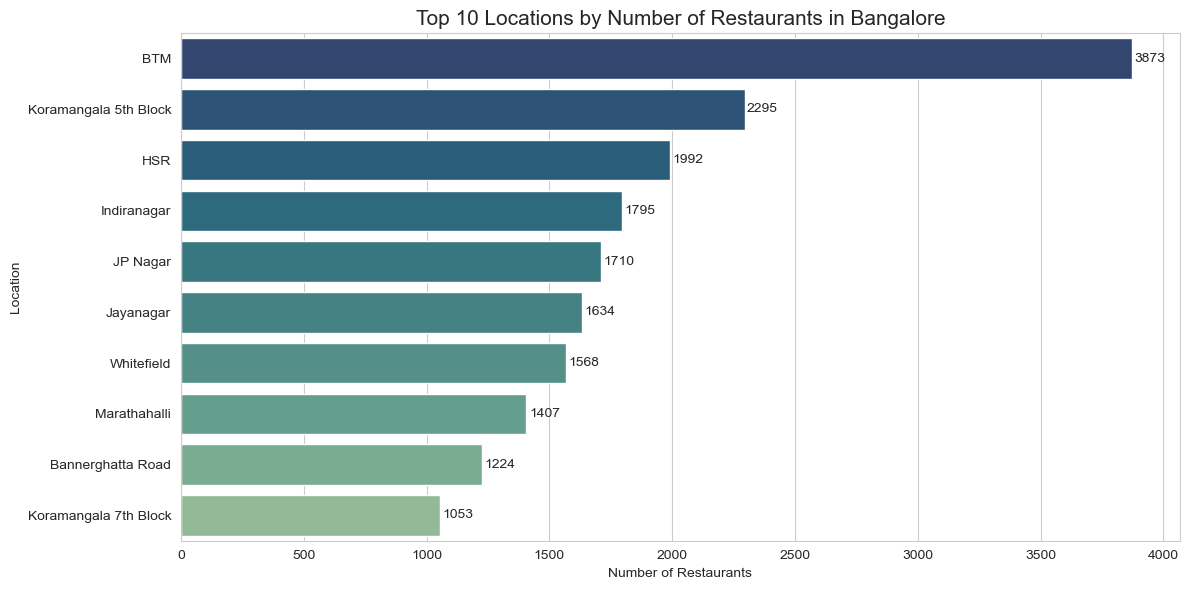

In [5]:
# Q1 — Visualization: Top 10 locations by number of restaurants
plt.figure(figsize=(12, 6))
sns.barplot(x=top_locations.values, 
            y=top_locations.index, 
            hue=top_locations.index,
            palette='crest_r',
            legend=False)
            
plt.title('Top 10 Locations by Number of Restaurants in Bangalore', 
          fontsize=15)
plt.xlabel('Number of Restaurants')
plt.ylabel('Location')

# Add value labels on each bar
for i, v in enumerate(top_locations.values): 
    plt.text(v + 10, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/q1_top_locations.png', dpi=150)
plt.show()

BTM Layout has the highest number of restaurants (3,873) — almost double of Koramangala 5th Block (2,295)


In [6]:
# Q2 — Which locations have the highest average ratings?
top_rated_locations = df.groupby('location')['rate']\
                        .mean()\
                        .sort_values(ascending=False)\
                        .head(10)\
                        .round(2)

print("Top 10 Locations by Average Rating:")
print(top_rated_locations)

Top 10 Locations by Average Rating:
location
Lavelle Road             4.14
Koramangala 3rd Block    4.02
St. Marks Road           4.02
Koramangala 5th Block    4.01
Church Street            3.99
Sankey Road              3.97
Koramangala 4th Block    3.92
Cunningham Road          3.90
Residency Road           3.86
Koramangala 7th Block    3.85
Name: rate, dtype: float64


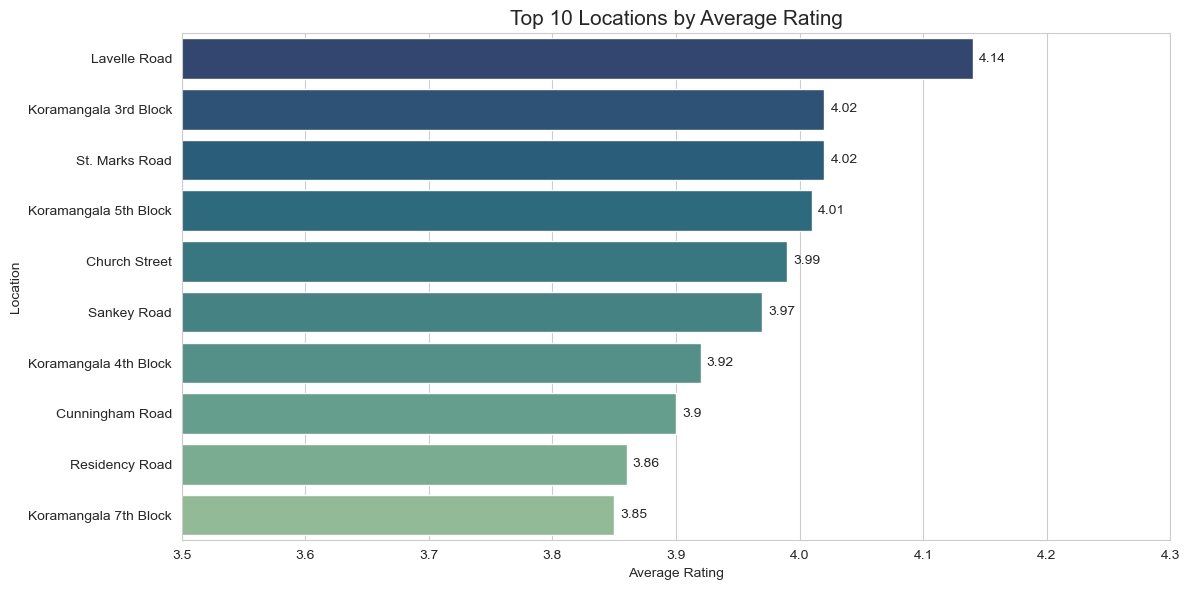

In [7]:
# Q2 — Visualization: Top 10 locations by average rating
plt.figure(figsize=(12, 6))
sns.barplot(x=top_rated_locations.values,
            y=top_rated_locations.index,
            hue=top_rated_locations.index,
            palette='crest_r',
            legend=False)

plt.title('Top 10 Locations by Average Rating', fontsize=15)
plt.xlabel('Average Rating')
plt.ylabel('Location')
plt.xlim(3.5, 4.3)  

for i, v in enumerate(top_rated_locations.values):
    plt.text(v + 0.005, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/q2_top_rated_locations.png', dpi=150)
plt.show()

## Q2 — Top 10 Locations by Average Rating
💡 Lavelle Road has the highest average rating (4.14) — a premium 
area with upscale restaurants. Koramangala dominates this list 
appearing 3 times, confirming it as Bangalore's top food destination!

In [8]:
# Q3 — Which locations are most expensive on average?
top_costly_locations = df.groupby('location')['approx_cost(for two people)']\
                         .mean()\
                         .sort_values(ascending=False)\
                         .head(10)\
                         .round(0)

print("Top 10 Most Expensive Locations:")
print(top_costly_locations)

Top 10 Most Expensive Locations:
location
Sankey Road         2583.0
Lavelle Road        1365.0
Race Course Road    1321.0
MG Road             1245.0
Infantry Road       1071.0
Residency Road      1028.0
Richmond Road        904.0
St. Marks Road       884.0
Langford Town        883.0
Cunningham Road      867.0
Name: approx_cost(for two people), dtype: float64


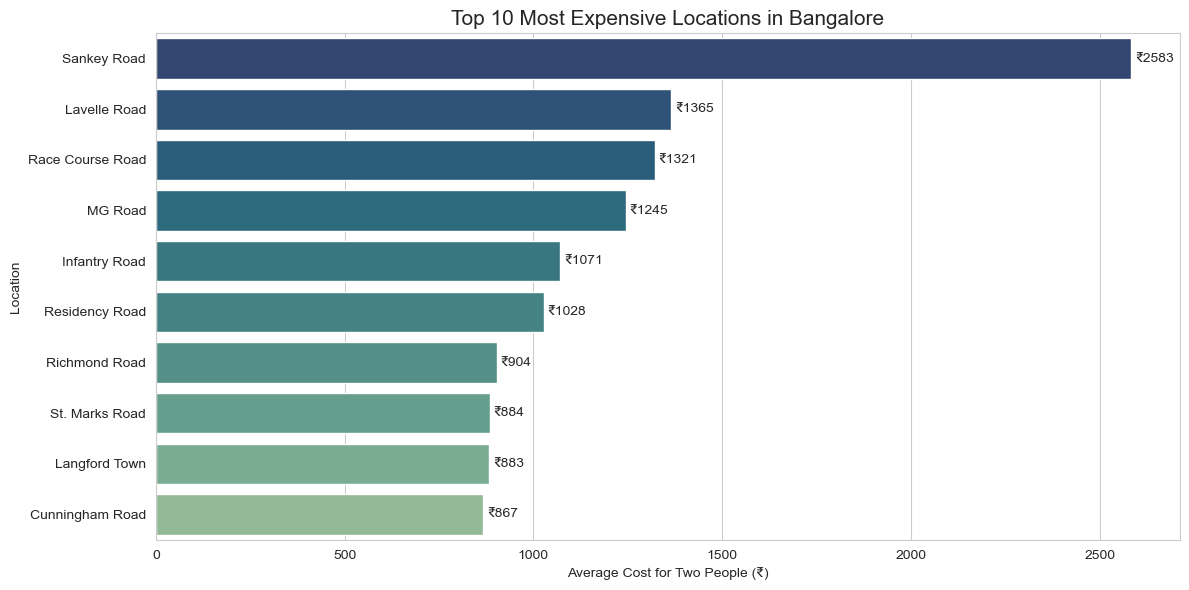

In [9]:
# Q3 — Visualization: Top 10 most expensive locations
plt.figure(figsize=(12, 6))
sns.barplot(x=top_costly_locations.values,
            y=top_costly_locations.index,
            hue=top_costly_locations.index,
            palette='crest_r',
            legend=False)

plt.title('Top 10 Most Expensive Locations in Bangalore', fontsize=15)
plt.xlabel('Average Cost for Two People (₹)')
plt.ylabel('Location')

for i, v in enumerate(top_costly_locations.values):   
    plt.text(v + 10, i, f'₹{int(v)}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/q3_costly_locations.png', dpi=150)
plt.show()

## Q3 — Most Expensive Locations
💡 Sankey Road is the most expensive area in Bangalore with an average 
cost of ₹2,583 for two — almost double of Lavelle Road (₹1,365). 
Lavelle Road appears in both top rated AND most expensive lists, 
confirming it as Bangalore's most premium dining destination!

In [10]:
# Q4 — What are the top 10 most popular cuisines?
# Each restaurant has multiple cuisines like "North Indian, Chinese"
# We need to split them and count individually

from collections import Counter

# Split cuisines by comma and flatten into one big list
all_cuisines = df['cuisines'].str.split(',').explode().str.strip()

top_cuisines = pd.Series(
    Counter(all_cuisines)
).sort_values(ascending=False).head(10)

print("Top 10 Most Popular Cuisines:")
print(top_cuisines)

Top 10 Most Popular Cuisines:
North Indian    17180
Chinese         12834
South Indian     6351
Fast Food        6314
Continental      5180
Biryani          5008
Cafe             4781
Desserts         4501
Beverages        3828
Italian          3167
dtype: int64


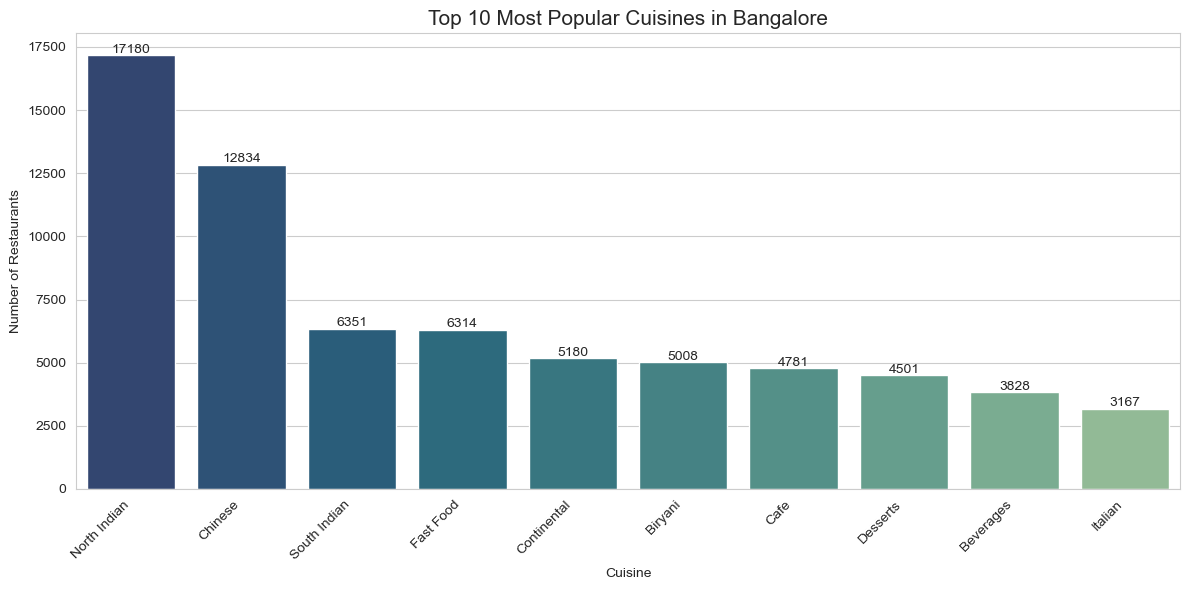

In [11]:
# Q4 — Visualization: Top 10 most popular cuisines
plt.figure(figsize=(12, 6))
sns.barplot(x=top_cuisines.index,
            y=top_cuisines.values,
            hue=top_cuisines.index,
            palette='crest_r',
            legend=False)

plt.title('Top 10 Most Popular Cuisines in Bangalore', fontsize=15)
plt.xlabel('Cuisine')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45, ha='right')

for i, v in enumerate(top_cuisines.values):
    plt.text(i, v + 100, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/q4_top_cuisines.png', dpi=150)
plt.show()


## Q4 — Most Popular Cuisines
💡 North Indian cuisine dominates Bangalore's food scene with 17,180 
restaurant listings — more than Chinese and South Indian combined! 
Biryani as a standalone category (5,008) shows Bangalore's deep 
love for this dish!

In [12]:
# Q5 — Which cuisine has the highest average rating?
# Step 1 — expand cuisines into individual rows
df_exploded = df.copy()
df_exploded['cuisines'] = df_exploded['cuisines'].str.split(',')
df_exploded = df_exploded.explode('cuisines')  
df_exploded['cuisines'] = df_exploded['cuisines'].str.strip()

# Step 2 — filter cuisines with at least 200 restaurants (avoid rare ones)
cuisine_counts = df_exploded['cuisines'].value_counts()
valid_cuisines = cuisine_counts[cuisine_counts >= 200].index
df_exploded = df_exploded[df_exploded['cuisines'].isin(valid_cuisines)]

# Step 3 — top 10 by average rating
top_rated_cuisines = df_exploded.groupby('cuisines')['rate']\
                                .mean()\
                                .sort_values(ascending=False)\
                                .head(10)\
                                .round(2)

print("Top 10 Cuisines by Average Rating:")
print(top_rated_cuisines)

Top 10 Cuisines by Average Rating:
cuisines
Japanese         4.26
Mediterranean    4.21
European         4.17
Asian            4.14
Steak            4.09
American         4.07
Salad            4.06
BBQ              4.05
Finger Food      4.00
Thai             3.99
Name: rate, dtype: float64


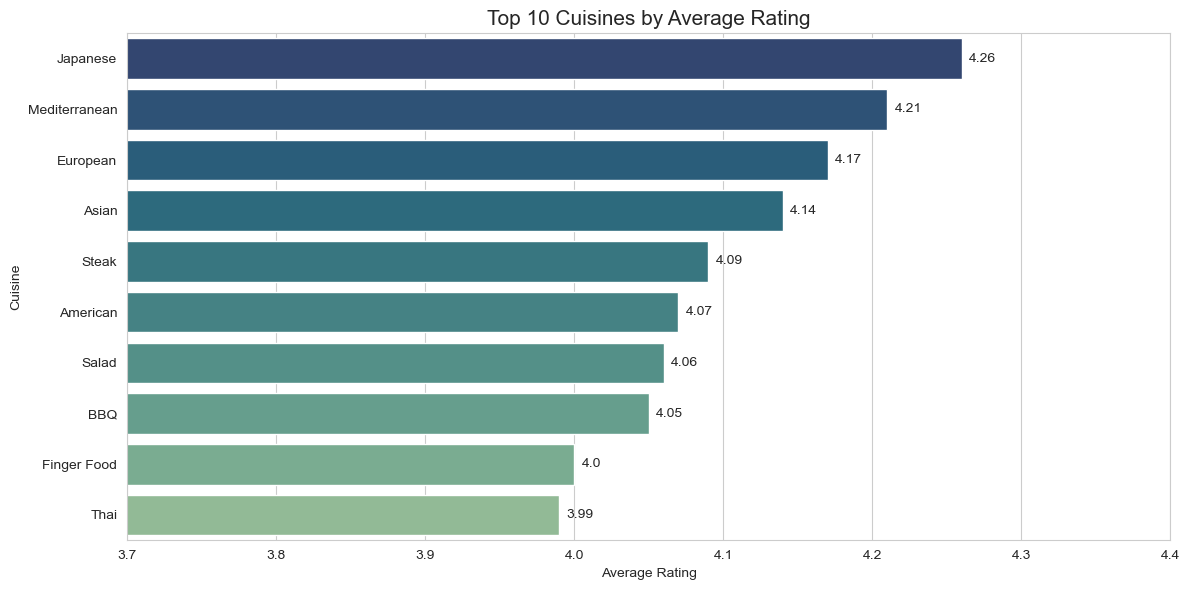

In [13]:
# Q5 — Visualization: Top 10 cuisines by average rating
plt.figure(figsize=(12, 6))
sns.barplot(x=top_rated_cuisines.values,
            y=top_rated_cuisines.index,
            hue=top_rated_cuisines.index,
            palette='crest_r',
            legend=False)

plt.title('Top 10 Cuisines by Average Rating', fontsize=15)
plt.xlabel('Average Rating')
plt.ylabel('Cuisine')
plt.xlim(3.7, 4.4)

for i, v in enumerate(top_rated_cuisines.values):
    plt.text(v + 0.005, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/q5_top_rated_cuisines.png', dpi=150)
plt.show()

## Q5 — Top Cuisines by Average Rating
💡 Premium international cuisines like Japanese (4.26), Mediterranean 
(4.21) and European (4.17) have the highest ratings — while popular 
cuisines like North Indian and Chinese don't appear here, suggesting 
that rarer cuisines attract more quality-focused restaurants!

In [14]:
# Q6 — Which cuisine is the most expensive?
top_costly_cuisines = df_exploded.groupby('cuisines')\
                                 ['approx_cost(for two people)']\
                                 .mean()\
                                 .sort_values(ascending=False)\
                                 .head(10)\
                                 .round(0)

print("Top 10 Most Expensive Cuisines:")
print(top_costly_cuisines)

Top 10 Most Expensive Cuisines:
cuisines
Japanese         1658.0
European         1548.0
Mediterranean    1468.0
Finger Food      1381.0
Asian            1289.0
Thai             1124.0
BBQ              1080.0
Continental      1047.0
Steak            1041.0
American         1034.0
Name: approx_cost(for two people), dtype: float64


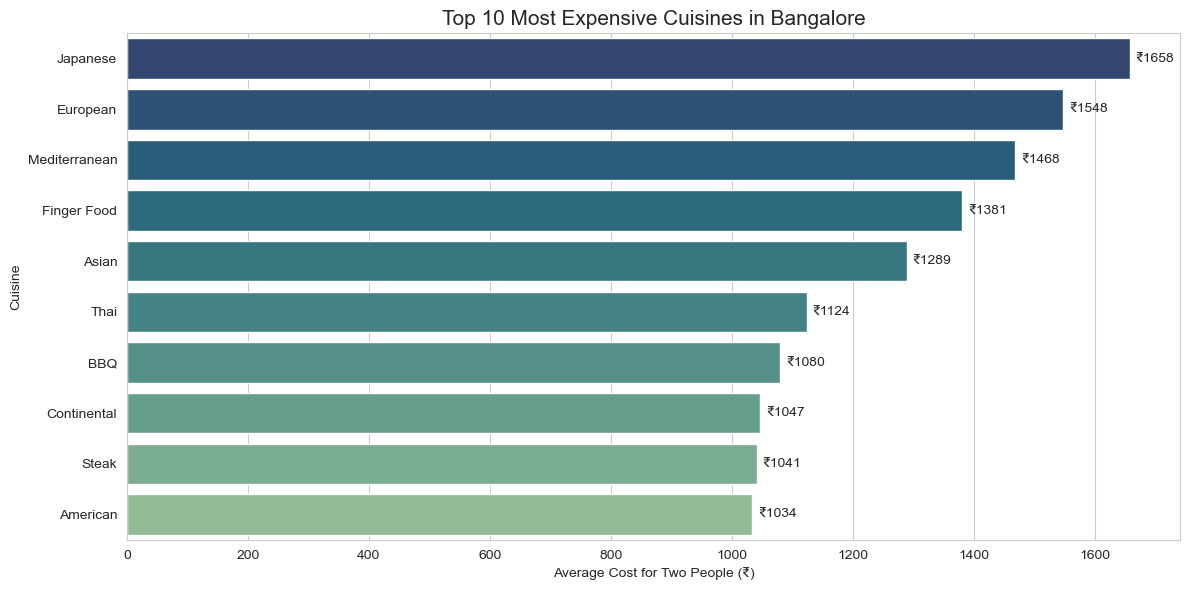

In [15]:
# Q6 — Visualization: Top 10 most expensive cuisines
plt.figure(figsize=(12, 6))
sns.barplot(x=top_costly_cuisines.values,
            y=top_costly_cuisines.index,
            hue=top_costly_cuisines.index,
            palette='crest_r',
            legend=False)

plt.title('Top 10 Most Expensive Cuisines in Bangalore', fontsize=15)
plt.xlabel('Average Cost for Two People (₹)')
plt.ylabel('Cuisine')

for i, v in enumerate(top_costly_cuisines.values):
    plt.text(v + 10, i, f'₹{int(v)}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/q6_costly_cuisines.png', dpi=150)
plt.show()

## Q6 — Most Expensive Cuisines
💡 Japanese cuisine is the most expensive at ₹1,658 for two — 
the same cuisines that are highest rated are also the most expensive, 
confirming that premium international cuisines attract both quality 
and higher price points in Bangalore!

In [16]:
# Q7 — Overall distribution of ratings
print(f"Average Rating:     {df['rate'].mean():.2f}")
print(f"Median Rating:      {df['rate'].median():.2f}")
print(f"Most Common Rating: {df['rate'].mode()[0]}")
print(f"Minimum Rating:     {df['rate'].min()}")
print(f"Maximum Rating:     {df['rate'].max()}")
print(f"\nRating Distribution:")
print(df['rate'].describe())

Average Rating:     3.70
Median Rating:      3.70
Most Common Rating: 3.9
Minimum Rating:     1.8
Maximum Rating:     4.9

Rating Distribution:
count    41190.000000
mean         3.701731
std          0.439929
min          1.800000
25%          3.400000
50%          3.700000
75%          4.000000
max          4.900000
Name: rate, dtype: float64


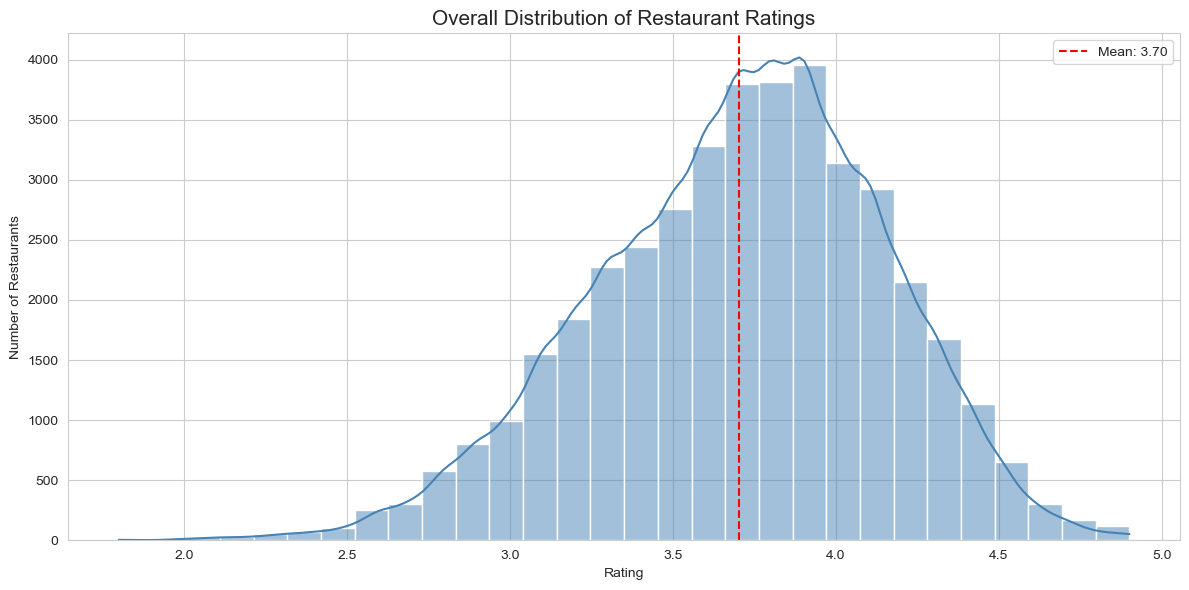

In [17]:
# Q7 — Visualization: Rating distribution
plt.figure(figsize=(12, 6))
sns.histplot(df['rate'], bins=30, kde=True,
             color='steelblue', edgecolor='white')

plt.title('Overall Distribution of Restaurant Ratings', fontsize=15)
plt.xlabel('Rating')
plt.ylabel('Number of Restaurants')
plt.axvline(df['rate'].mean(), color='red',
            linestyle='--',
            label=f"Mean: {df['rate'].mean():.2f}")
plt.legend()

plt.tight_layout()
plt.savefig('outputs/q7_rating_distribution.png', dpi=150)
plt.show()

## Q7 — Overall Rating Distribution
Restaurant ratings in Bangalore follow a left-skewed distribution 
peaking around 3.8–3.9. The average rating is 3.70 and 75% of 
restaurants rate below 4.0 — meaning only the top 25% of restaurants 
achieve a 4.0+ rating!

In [18]:
# Q8 — Does online ordering affect ratings?
print("── Average Rating by Online Order ──")
print(df.groupby('online_order')['rate'].mean().round(2))
print("\n── Count by Online Order ──")
print(df['online_order'].value_counts())

── Average Rating by Online Order ──
online_order
No     3.66
Yes    3.72
Name: rate, dtype: float64

── Count by Online Order ──
online_order
Yes    27046
No     14144
Name: count, dtype: int64


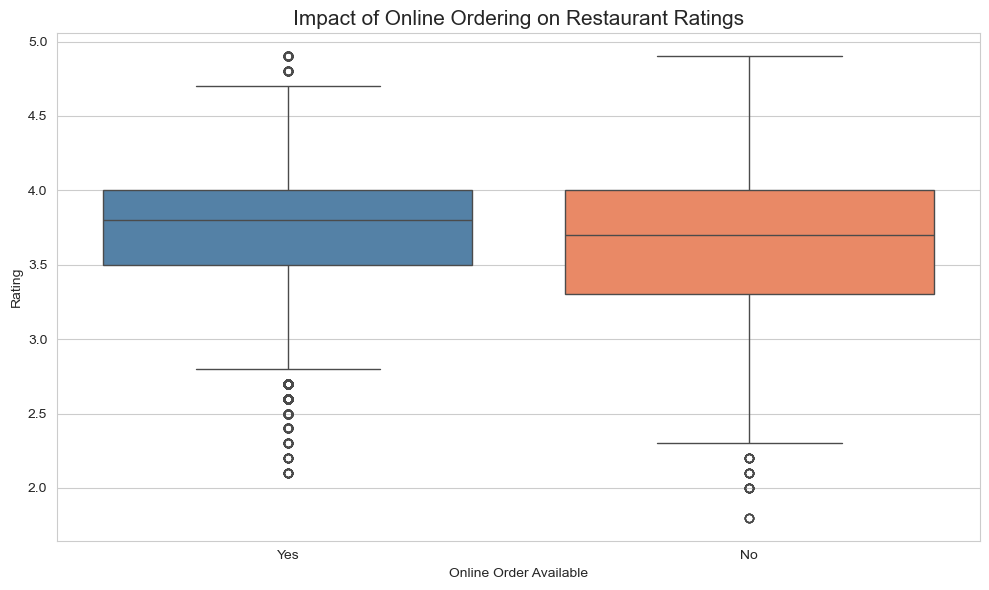

In [19]:
# Q8 — Visualization: Online ordering vs rating (Box Plot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='online_order', y='rate', 
            data=df,
            hue='online_order',
            palette={'Yes': 'steelblue', 'No': 'coral'},
            legend=False)

plt.title('Impact of Online Ordering on Restaurant Ratings', fontsize=15)
plt.xlabel('Online Order Available')
plt.ylabel('Rating')

plt.tight_layout()
plt.savefig('outputs/q8_online_order_rating.png', dpi=150)
plt.show()

## Q8 — Online Ordering vs Ratings
💡 Restaurants with online ordering (avg 3.72) rate slightly higher 
than those without (avg 3.66). The Yes group also shows more 
consistent ratings with a tighter distribution — suggesting that 
restaurants offering online ordering tend to maintain better 
overall quality!

In [20]:
# Q9 — Does table booking affect ratings?
print("── Average Rating by Table Booking ──")
print(df.groupby('book_table')['rate'].mean().round(2))
print("\n── Count by Table Booking ──")
print(df['book_table'].value_counts())

── Average Rating by Table Booking ──
book_table
No     3.62
Yes    4.14
Name: rate, dtype: float64

── Count by Table Booking ──
book_table
No     34915
Yes     6275
Name: count, dtype: int64


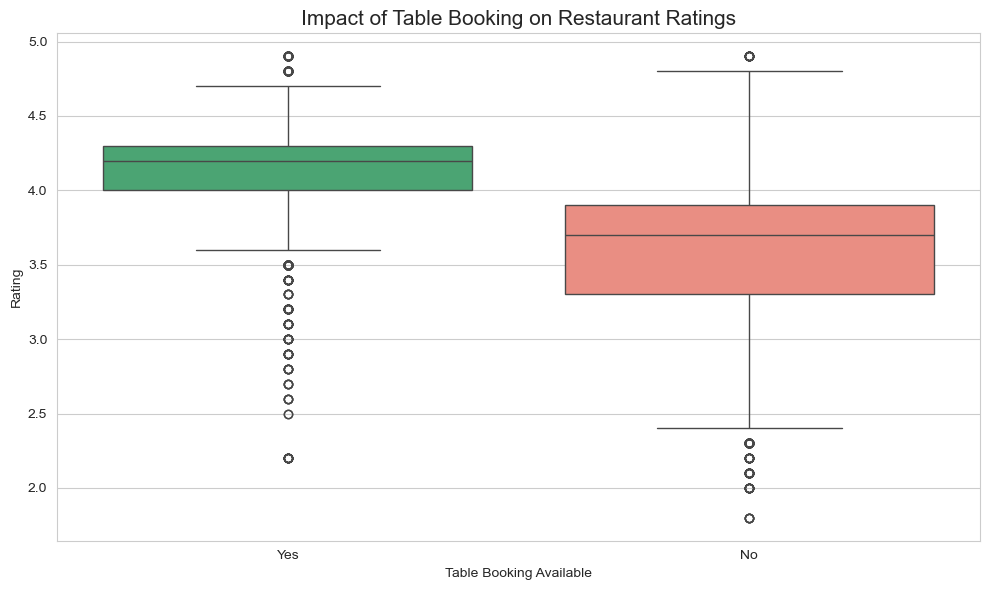

In [21]:
# Q9 — Visualization: Table booking vs rating (Box Plot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='book_table', y='rate',
            data=df,
            hue='book_table',
            palette={'Yes': 'mediumseagreen', 'No': 'salmon'},
            legend=False)

plt.title('Impact of Table Booking on Restaurant Ratings', fontsize=15)
plt.xlabel('Table Booking Available')
plt.ylabel('Rating')

plt.tight_layout()
plt.savefig('outputs/q9_table_booking_rating.png', dpi=150)
plt.show()

## Q9 — Table Booking vs Ratings
💡 Restaurants with table booking have a significantly higher average 
rating (4.14) compared to those without (3.62) — a massive 0.52 
difference! This is the strongest factor affecting ratings in our 
entire analysis. Premium restaurants that offer table booking 
consistently deliver better dining experiences!

In [22]:
# Q10 — What is the cost distribution?
print(f"Average Cost for Two:  ₹{df['approx_cost(for two people)'].mean():.0f}")
print(f"Median Cost for Two:   ₹{df['approx_cost(for two people)'].median():.0f}")
print(f"Minimum Cost for Two:  ₹{df['approx_cost(for two people)'].min():.0f}")
print(f"Maximum Cost for Two:  ₹{df['approx_cost(for two people)'].max():.0f}")
print(f"\nCost Distribution:")
print(df['approx_cost(for two people)'].describe())

Average Cost for Two:  ₹604
Median Cost for Two:   ₹500
Minimum Cost for Two:  ₹40
Maximum Cost for Two:  ₹6000

Cost Distribution:
count    41190.000000
mean       603.545909
std        464.651174
min         40.000000
25%        300.000000
50%        500.000000
75%        750.000000
max       6000.000000
Name: approx_cost(for two people), dtype: float64


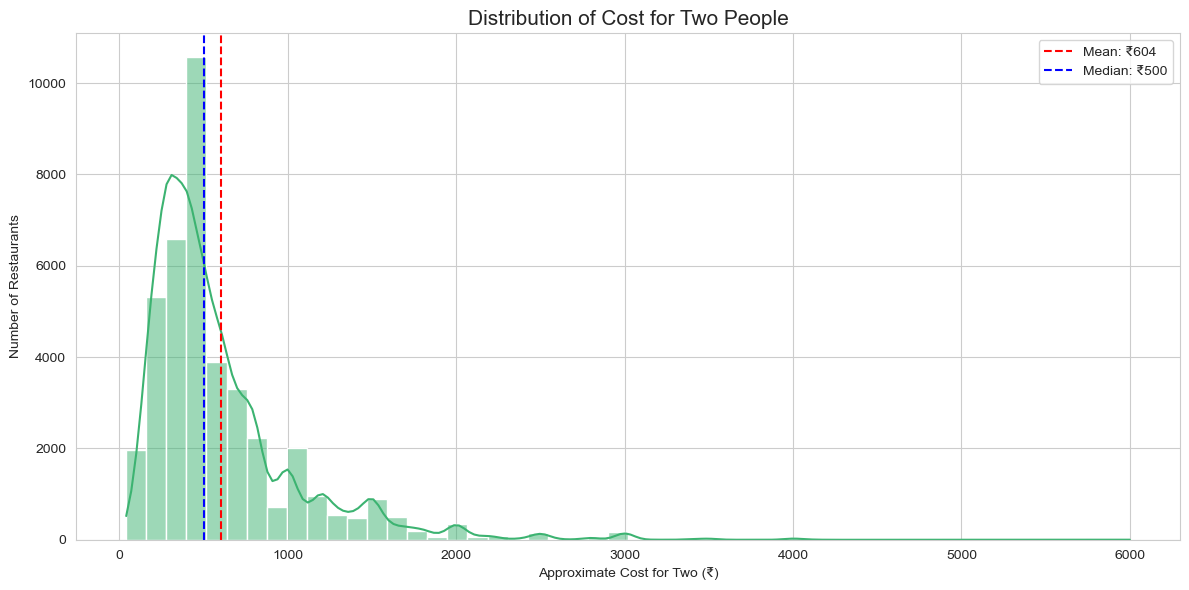

In [23]:
# Q10 — Visualization: Cost distribution
plt.figure(figsize=(12, 6))
sns.histplot(df['approx_cost(for two people)'], 
             bins=50, kde=True,
             color='mediumseagreen', 
             edgecolor='white')

plt.title('Distribution of Cost for Two People', fontsize=15)
plt.xlabel('Approximate Cost for Two (₹)')
plt.ylabel('Number of Restaurants')
plt.axvline(df['approx_cost(for two people)'].mean(), 
            color='red', linestyle='--',
            label=f"Mean: ₹{df['approx_cost(for two people)'].mean():.0f}")
plt.axvline(df['approx_cost(for two people)'].median(), 
            color='blue', linestyle='--',
            label=f"Median: ₹{df['approx_cost(for two people)'].median():.0f}")
plt.legend()

plt.tight_layout()
plt.savefig('outputs/q10_cost_distribution.png', dpi=150)
plt.show()

## Q10 — Cost Distribution
💡 Most Bangalore restaurants are budget friendly — majority fall 
in the ₹300–₹500 range for two people. The mean (₹604) is higher 
than median (₹500) due to a few premium restaurants pulling the 
average up. 75% of all restaurants cost under ₹750 for two!

In [24]:
# Q11 — Which restaurant type is most expensive?
cost_by_type = df.groupby('rest_type')['approx_cost(for two people)']\
                 .mean()\
                 .sort_values(ascending=False)\
                 .head(10)\
                 .round(0)

print("Average Cost by Restaurant Type:")
print(cost_by_type)

Average Cost by Restaurant Type:
rest_type
Fine Dining, Bar             3015.0
Fine Dining, Microbrewery    3000.0
Fine Dining, Lounge          3000.0
Fine Dining                  2723.0
Bar, Lounge                  2450.0
Club, Casual Dining          2400.0
Club                         2150.0
Lounge, Bar                  2028.0
Lounge, Microbrewery         2000.0
Bar, Quick Bites             2000.0
Name: approx_cost(for two people), dtype: float64


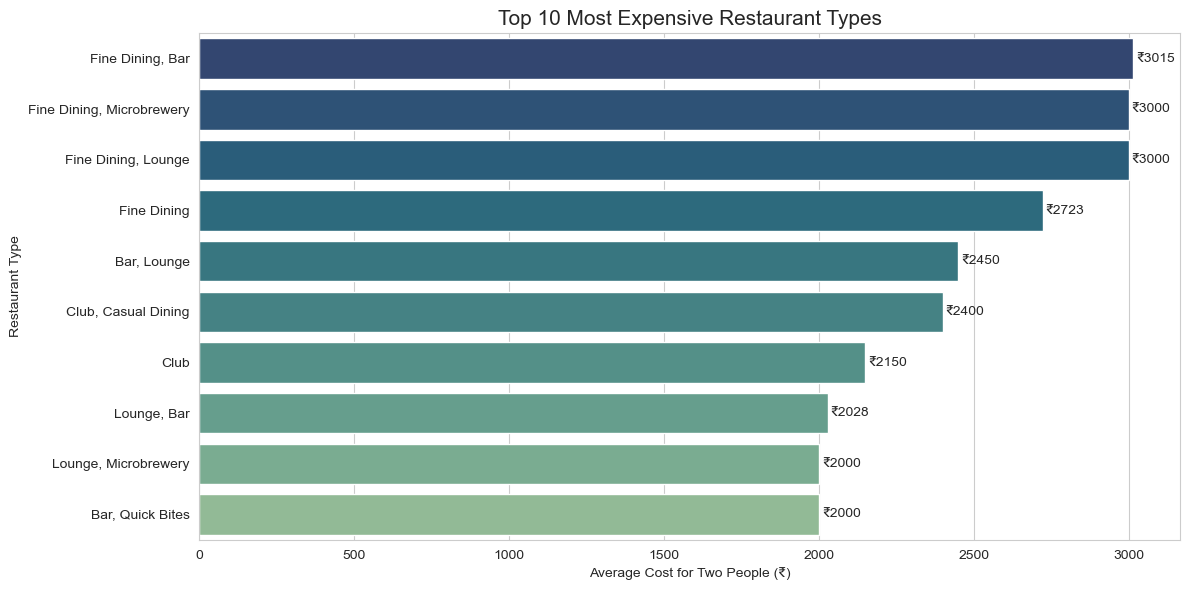

In [25]:
# Q11 — Visualization: Cost by restaurant type
plt.figure(figsize=(12, 6))
sns.barplot(x=cost_by_type.values,
            y=cost_by_type.index,
            hue=cost_by_type.index,
            palette='crest_r',
            legend=False)

plt.title('Top 10 Most Expensive Restaurant Types', fontsize=15)
plt.xlabel('Average Cost for Two People (₹)')
plt.ylabel('Restaurant Type')

for i, v in enumerate(cost_by_type.values):
    plt.text(v + 10, i, f'₹{int(v)}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/q11_cost_by_type.png', dpi=150)
plt.show()

## Q11 — Cost by Restaurant Type
💡 Fine Dining combinations dominate the most expensive category — 
Fine Dining + Bar tops at ₹3,015 for two. Bar and Lounge 
combinations consistently appear in the top 10, confirming that 
nightlife + dining experiences command premium pricing in Bangalore!

In [26]:
# Q12 — Which restaurant type is most common?
common_types = df['rest_type'].value_counts().head(10)

print("Top 10 Most Common Restaurant Types:")
print(common_types)

Top 10 Most Common Restaurant Types:
rest_type
Quick Bites           13861
Casual Dining          9597
Cafe                   3365
Dessert Parlor         1848
Delivery               1666
Takeaway, Delivery     1276
Casual Dining, Bar     1087
Bakery                  704
Bar                     640
Beverage Shop           638
Name: count, dtype: int64


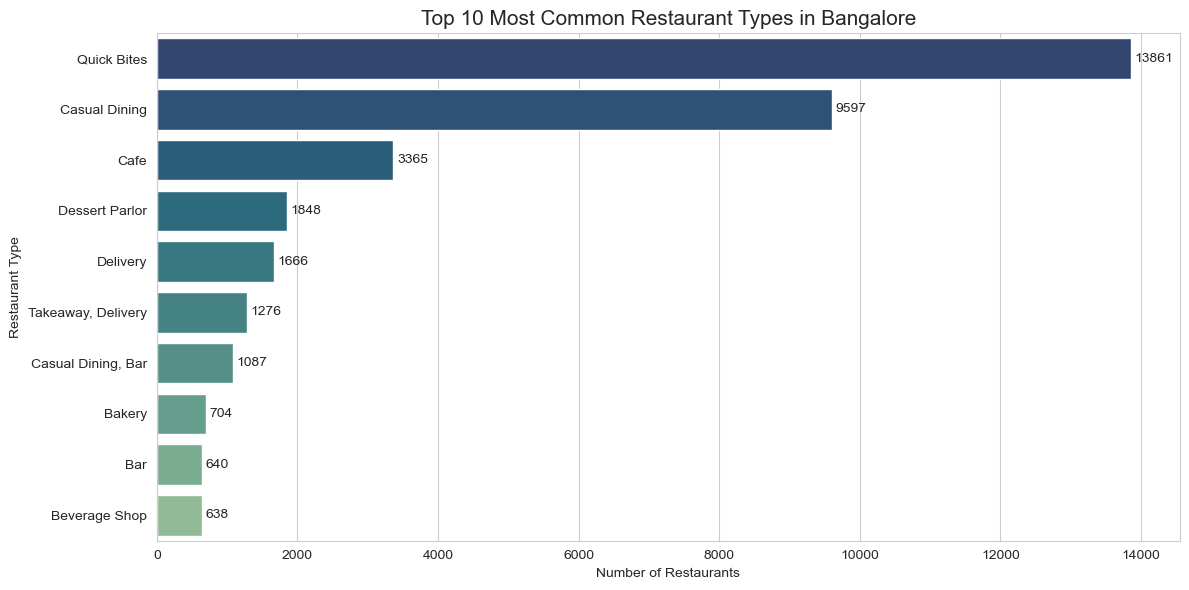

In [27]:
# Q12 — Visualization: Most common restaurant types
plt.figure(figsize=(12, 6))
sns.barplot(x=common_types.values,
            y=common_types.index,
            hue=common_types.index,
            palette='crest_r',
            legend=False)

plt.title('Top 10 Most Common Restaurant Types in Bangalore', fontsize=15)
plt.xlabel('Number of Restaurants')
plt.ylabel('Restaurant Type')

for i, v in enumerate(common_types.values):
    plt.text(v + 50, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/q12_common_rest_types.png', dpi=150)
plt.show()

## Q12 — Most Common Restaurant Types
💡 Quick Bites is the most common restaurant type (13,861) — 
almost 1.5x more than Casual Dining (9,597). This reflects 
Bangalore's fast-paced tech culture where people prefer quick, 
affordable meals over sit-down dining experiences!

In [28]:
# Q13 — Which restaurant type has the best average rating?
# Filter types with at least 50 restaurants
type_counts = df['rest_type'].value_counts()
valid_types = type_counts[type_counts >= 50].index

best_rated_types = df[df['rest_type'].isin(valid_types)]\
                    .groupby('rest_type')['rate']\
                    .mean()\
                    .sort_values(ascending=False)\
                    .head(10)\
                    .round(2)

print("Top 10 Best Rated Restaurant Types:")
print(best_rated_types)

Top 10 Best Rated Restaurant Types:
rest_type
Pub, Microbrewery              4.45
Microbrewery, Casual Dining    4.37
Casual Dining, Cafe            4.20
Casual Dining, Pub             4.18
Fine Dining                    4.15
Cafe, Dessert Parlor           4.15
Dessert Parlor, Cafe           4.14
Bar, Casual Dining             4.12
Pub, Casual Dining             4.09
Casual Dining, Bar             4.08
Name: rate, dtype: float64


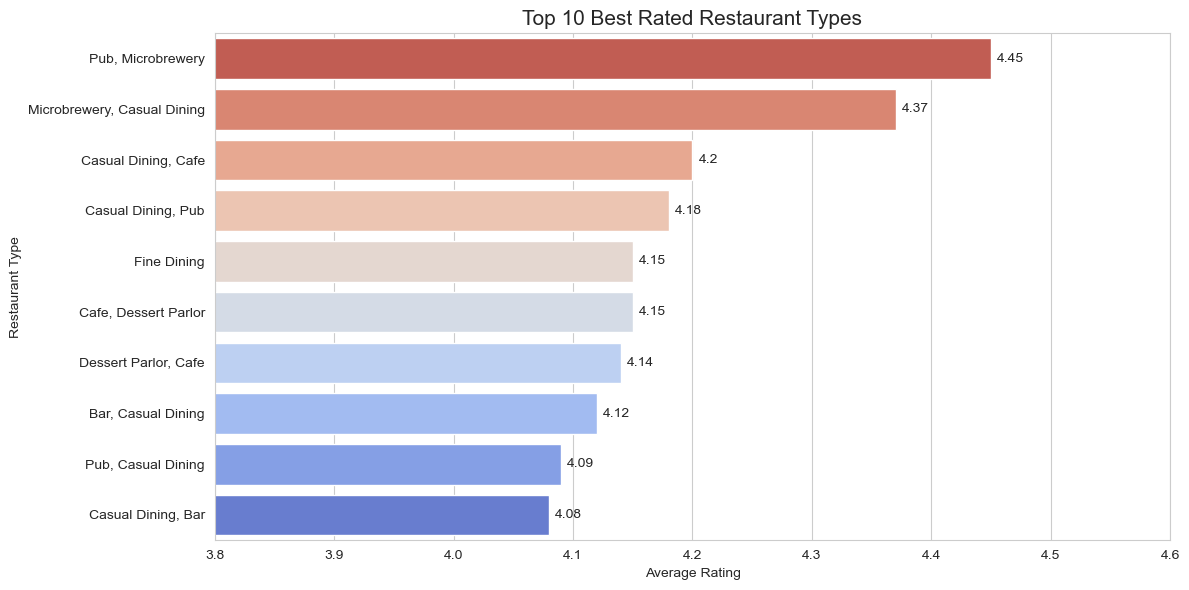

In [29]:
# Q13 — Visualization: Best rated restaurant types
plt.figure(figsize=(12, 6))
sns.barplot(x=best_rated_types.values,
            y=best_rated_types.index,
            hue=best_rated_types.index,
            palette='coolwarm_r',
            legend=False)

plt.title('Top 10 Best Rated Restaurant Types', fontsize=15)
plt.xlabel('Average Rating')
plt.ylabel('Restaurant Type')
plt.xlim(3.8, 4.6)

for i, v in enumerate(best_rated_types.values):
    plt.text(v + 0.005, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/q13_best_rated_types.png', dpi=150)
plt.show()

## Q13 — Best Rated Restaurant Types
💡 Pub + Microbrewery (4.45) is the highest rated restaurant type — 
reflecting Bangalore's thriving craft beer culture! Casual Dining 
appears in 6 out of 10 top rated combinations, confirming it as 
Bangalore's most loved dining format!

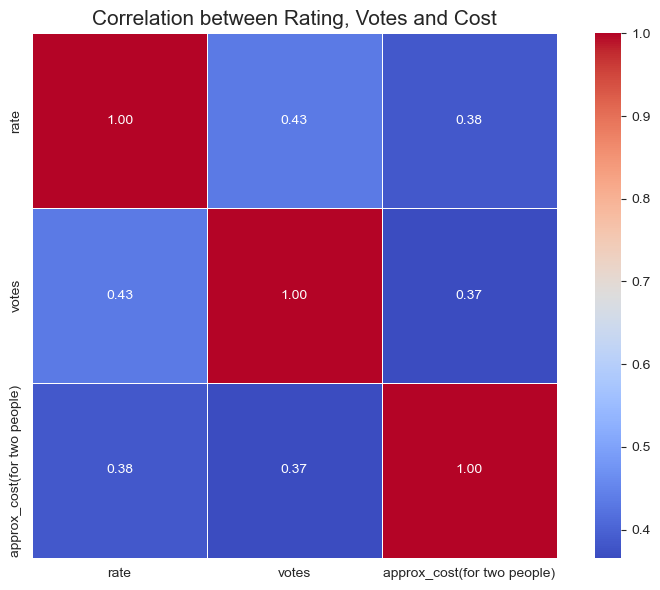


Correlation Values:
                                 rate     votes  approx_cost(for two people)
rate                         1.000000  0.434746                     0.384481
votes                        0.434746  1.000000                     0.365723
approx_cost(for two people)  0.384481  0.365723                     1.000000


In [30]:
# Q14 — Correlation Heatmap
plt.figure(figsize=(8, 6))
corr = df[['rate', 'votes', 'approx_cost(for two people)']].corr()

sns.heatmap(corr, 
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            square=True)

plt.title('Correlation between Rating, Votes and Cost', fontsize=15)

plt.tight_layout()
plt.savefig('outputs/q14_correlation_heatmap.png', dpi=150)
plt.show()

print("\nCorrelation Values:")
print(corr)

## Q14 — Correlation Analysis
💡 Rating has a moderate positive correlation with both votes (0.43) 
and cost (0.38) — meaning popular and expensive restaurants tend to 
rate slightly higher. However no strong correlation exists (would 
need 0.7+), suggesting restaurant quality depends on many factors 
beyond just price and popularity!
```

---

**🎊 ANALYSIS COMPLETE! Here's what you built:**
```
✅ 14 questions answered
✅ 14 visualizations created
✅ 5 bar charts
✅ 2 histograms
✅ 2 box plots
✅ 1 heatmap
✅ 14 markdown insights
✅ 14 PNG files saved in outputs folder

# 📊 Key Insights Summary

## Top 7 Findings from this Analysis:

1. **BTM Layout** dominates Bangalore with 3,873 restaurants — 
   almost double of Koramangala 5th Block (2,295)

2. **Lavelle Road** is Bangalore's premium dining destination — 
   highest average rating (4.14) AND most expensive (₹1,365 for two)

3. **North Indian cuisine** dominates with 17,180 listings — 
   more than Chinese and South Indian combined!

4. **Japanese cuisine** is the highest rated (4.26) AND most 
   expensive (₹1,658) — premium international cuisines rule both lists

5. **Table booking** has the strongest impact on ratings — 
   restaurants with booking average 4.14 vs 3.62 without (0.52 gap!)

6. **Quick Bites** is the most common restaurant type (13,861) — 
   reflecting Bangalore's fast-paced tech culture

7. **Pub + Microbrewery** is the highest rated restaurant type (4.45) 
   — Bangalore's craft beer culture drives dining excellence!

---
*Analysis performed on Zomato Bangalore dataset | 41,190 restaurants*